In [ ]:
from google.colab import files
uploaded = files.upload()

Saving skincare-labeled.xlsx to skincare-labeled (1).xlsx


In [ ]:
import pandas as pd

data = pd.read_excel("skincare-labeled.xlsx")

# Data sudah diberi label sentimen secara manual (0=Positive, 1=Neutral, 2=Negative)
data.head()

,text,clean_text,tokenized_text,normalized_text,label
0,Rejuvenate & transform your skin with these e...,rejuvenate transform your skin with these effe...,"['rejuvenate', 'transform', 'your', 'skin', 'w...",rejuvenate transform your skin with these effe...,0
1,"Keknya skinker/? Ini sama kayak disini, dia ma...","keknya skinker ? ini sama kayak disini, dia ma...","['keknya', 'skinker', '?', 'ini', 'sama', 'kay...","kayaknya skincare ? ini sama kayak disini , di...",2
2,Tuhkan emang skincare ini bagus banget buat ny...,tuhkan emang skincare ini bagus banget buat ny...,"['tuhkan', 'emang', 'skincare', 'ini', 'bagus'...",tuhkan memang skincare ini bagus banget buat n...,0
3,Btw skintype aku oily acne prone. Dari dulu ka...,btw skintype aku oily acne prone. dari dulu ka...,"['btw', 'skintype', 'aku', 'oily', 'acne', 'pr...",btw skin type aku oily acne prone . dari dulu ...,2
4,"@ohmybeautybank BENER SEKALIIIII, sebagus ituu...","bener sekaliiiii, sebagus ituuu, pake yang ijo...","['bener', 'sekaliiiii', ',', 'sebagus', 'ituuu...","benar sekali , sebagus itu , pakai yang ijo je...",0


In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_nb = 1
fold_svm = 1

nb_results = []

svm_results = []

label_map = {0: "Positive", 1: "Neutral", 2: "Negative"}

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [ ]:
# TF-IDF dan Pipeline untuk Naive Bayes
tfidf_nb = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
nb_pipeline = Pipeline([
    ('tfidf', tfidf_nb),
    ('clf', MultinomialNB())
])

nb_param_grid = {
    'clf__alpha': [0.1, 0.5, 1.0, 1.5, 2.0]
}


===== Naive Bayes FOLD 1 =====
Parameter Naive Bayes Terbaik: {'clf__alpha': 0.1}

Sentiment Distribution Naive Bayes Fold 1
          Jumlah  Persentase (%)
Positive     152           26.76
Neutral      319           56.16
Negative      97           17.08


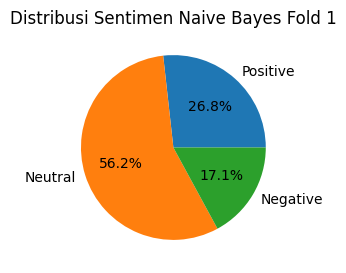


Classification Report Naive Bayes Fold 1
              precision    recall  f1-score   support

    Positive       0.47      0.63      0.54       113
     Neutral       0.85      0.70      0.77       386
    Negative       0.33      0.46      0.39        69

    accuracy                           0.66       568
   macro avg       0.55      0.60      0.56       568
weighted avg       0.71      0.66      0.67       568


===== Naive Bayes FOLD 2 =====
Parameter Naive Bayes Terbaik: {'clf__alpha': 0.1}

Sentiment Distribution Naive Bayes Fold 2
          Jumlah  Persentase (%)
Positive     160           28.17
Neutral      312           54.93
Negative      96           16.90


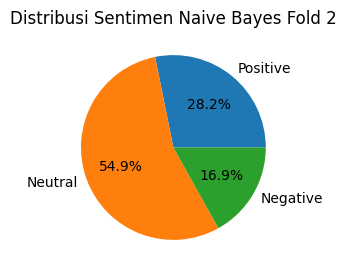


Classification Report Naive Bayes Fold 2
              precision    recall  f1-score   support

    Positive       0.42      0.60      0.50       113
     Neutral       0.81      0.66      0.73       386
    Negative       0.33      0.46      0.39        69

    accuracy                           0.62       568
   macro avg       0.52      0.57      0.54       568
weighted avg       0.68      0.62      0.64       568


===== Naive Bayes FOLD 3 =====
Parameter Naive Bayes Terbaik: {'clf__alpha': 0.1}

Sentiment Distribution Naive Bayes Fold 3
          Jumlah  Persentase (%)
Positive     150           26.46
Neutral      317           55.91
Negative     100           17.64


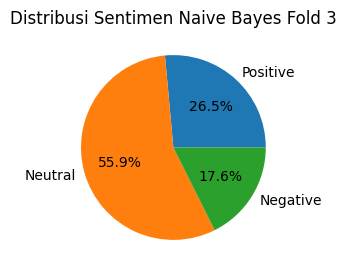


Classification Report Naive Bayes Fold 3
              precision    recall  f1-score   support

    Positive       0.46      0.61      0.52       113
     Neutral       0.87      0.71      0.78       385
    Negative       0.37      0.54      0.44        69

    accuracy                           0.67       567
   macro avg       0.57      0.62      0.58       567
weighted avg       0.73      0.67      0.69       567


===== Naive Bayes FOLD 4 =====
Parameter Naive Bayes Terbaik: {'clf__alpha': 0.1}

Sentiment Distribution Naive Bayes Fold 4
          Jumlah  Persentase (%)
Positive     180           31.75
Neutral      309           54.50
Negative      78           13.76


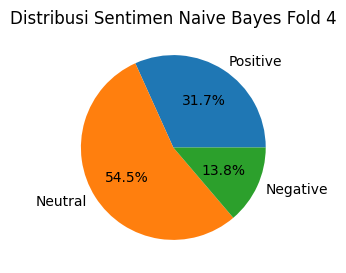


Classification Report Naive Bayes Fold 4
              precision    recall  f1-score   support

    Positive       0.41      0.65      0.51       113
     Neutral       0.84      0.67      0.75       385
    Negative       0.45      0.51      0.48        69

    accuracy                           0.65       567
   macro avg       0.57      0.61      0.58       567
weighted avg       0.71      0.65      0.67       567


===== Naive Bayes FOLD 5 =====
Parameter Naive Bayes Terbaik: {'clf__alpha': 0.1}

Sentiment Distribution Naive Bayes Fold 5
          Jumlah  Persentase (%)
Positive     161           28.40
Neutral      318           56.08
Negative      88           15.52


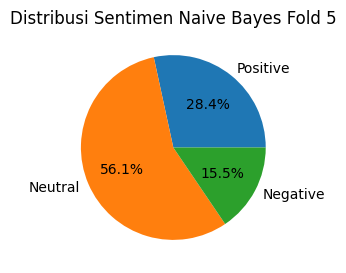


Classification Report Naive Bayes Fold 5
              precision    recall  f1-score   support

    Positive       0.44      0.63      0.52       113
     Neutral       0.84      0.70      0.76       385
    Negative       0.42      0.54      0.47        69

    accuracy                           0.66       567
   macro avg       0.57      0.62      0.58       567
weighted avg       0.71      0.66      0.68       567



In [ ]:
# Iterasi untuk setiap fold
for train_idx, eval_idx in skf.split(data["normalized_text"], data["label"]):
    print(f"\n===== Naive Bayes FOLD {fold_nb} =====")

    # Bagi data menjadi data latih (train) dan data evaluasi (eval)
    X_train, y_train = data["normalized_text"].iloc[train_idx], data["label"].iloc[train_idx]
    X_eval, y_eval = data["normalized_text"].iloc[eval_idx], data["label"].iloc[eval_idx]

    # Menghitung bobot manual
    classes_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    weight_dict = dict(zip(np.unique(y_train), classes_weights))
    sample_weights = y_train.map(weight_dict).values

    # Grid Search & Training
    nb_grid = GridSearchCV(nb_pipeline, nb_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
    nb_grid.fit(X_train, y_train, clf__sample_weight=sample_weights)

    print(f"Parameter Naive Bayes Terbaik: {nb_grid.best_params_}")

    # Prediksi
    y_pred_nb = nb_grid.best_estimator_.predict(X_eval)

    # Hitung metrik evaluasi
    acc = accuracy_score(y_eval, y_pred_nb)
    precision, recall, f1, _ = precision_recall_fscore_support(y_eval, y_pred_nb, average='macro', zero_division=0)

    nb_results.append({
        "fold": fold_nb,
        "best_params": nb_grid.best_params_,
        "accuracy_nb": acc,
        "precision_macro_nb": precision,
        "recall_macro_nb": recall,
        "f1_macro_nb": f1
    })

    # Hitung distribusi sentimen
    sentiment_dist = pd.Series(y_pred_nb).value_counts().sort_index()
    sentiment_dist.index = sentiment_dist.index.map(label_map)
    sentiment_summary = pd.DataFrame({
        "Jumlah": sentiment_dist,
        "Persentase (%)": (sentiment_dist / sentiment_dist.sum() * 100).round(2)
    })

    print(f"\nSentiment Distribution Naive Bayes Fold {fold_nb}")
    print(sentiment_summary)

    # Pie Chart Distribusi Sentimen
    sentiment_summary["Jumlah"].plot(kind="pie", autopct="%1.1f%%", figsize=(3,3), title=f"Distribusi Sentimen Naive Bayes Fold {fold_nb}")
    plt.ylabel("")
    plt.show()

    # Classification Report
    print(f"\nClassification Report Naive Bayes Fold {fold_nb}")
    print(classification_report(y_eval, y_pred_nb, target_names=["Positive", "Neutral", "Negative"]))

    # Lanjut ke fold berikutnya
    fold_nb += 1

In [ ]:
# Mengambil nilai F1-Score Macro dari seluruh fold
f1_nb = [result["f1_macro_nb"] for result in nb_results]

print("F1-Score Macro Naive Bayes per Fold:", f1_nb)

F1-Score Macro Naive Bayes per Fold: [0.5624495573623277, 0.5379469941074525, 0.5820201449527763, 0.5759025415466289, 0.5840108039946051]


In [ ]:
avg_accuracy_nb = np.mean([result["accuracy_nb"] for result in nb_results])
avg_precision_nb = np.mean([result["precision_macro_nb"] for result in nb_results])
avg_recall_nb = np.mean([result["recall_macro_nb"] for result in nb_results])
avg_f1score_nb = np.mean([result["f1_macro_nb"] for result in nb_results])

print(f"Average Naive Bayes Accuracy : {avg_accuracy_nb:.4f}")
print(f"Average Naive Bayes Precision: {avg_precision_nb:.4f}")
print(f"Average Naive Bayes Recall   : {avg_recall_nb:.4f}")
print(f"Average Naive Bayes F1-Score : {avg_f1score_nb:.4f}")

Average Naive Bayes Accuracy : 0.6528
Average Naive Bayes Precision: 0.5544
Average Naive Bayes Recall   : 0.6048
Average Naive Bayes F1-Score : 0.5685


**Step 5: SVM (Kernel Linear)**

In [ ]:
# TF-IDF dan Pipeline untuk SVM
tfidf_svm = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
svm_pipeline = Pipeline([
    ('tfidf', tfidf_svm),
    # Tetapkan kernel='linear' langsung di dalam SVC agar menjadi parameter tetap
    ('clf', SVC(kernel='linear', class_weight='balanced', random_state=42))
])

svm_param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100]
}


===== SVM FOLD 1 =====
Parameter SVM Terbaik: {'clf__C': 10}

Sentiment Distribution SVM Fold 1
          Jumlah  Persentase (%)
Positive     116           20.42
Neutral      403           70.95
Negative      49            8.63


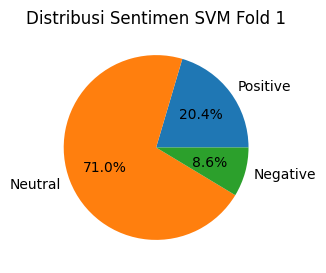


Classification Report SVM Fold 1
              precision    recall  f1-score   support

    Positive       0.66      0.68      0.67       113
     Neutral       0.85      0.89      0.87       386
    Negative       0.71      0.51      0.59        69

    accuracy                           0.80       568
   macro avg       0.74      0.69      0.71       568
weighted avg       0.80      0.80      0.80       568


===== SVM FOLD 2 =====
Parameter SVM Terbaik: {'clf__C': 100}

Sentiment Distribution SVM Fold 2
          Jumlah  Persentase (%)
Positive     101           17.78
Neutral      410           72.18
Negative      57           10.04


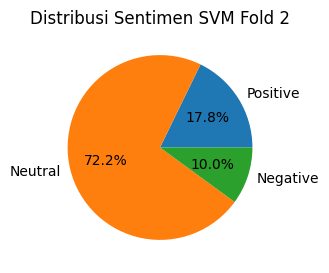


Classification Report SVM Fold 2
              precision    recall  f1-score   support

    Positive       0.65      0.58      0.62       113
     Neutral       0.84      0.90      0.87       386
    Negative       0.67      0.55      0.60        69

    accuracy                           0.79       568
   macro avg       0.72      0.68      0.70       568
weighted avg       0.78      0.79      0.79       568


===== SVM FOLD 3 =====
Parameter SVM Terbaik: {'clf__C': 100}

Sentiment Distribution SVM Fold 3
          Jumlah  Persentase (%)
Positive     104           18.34
Neutral      407           71.78
Negative      56            9.88


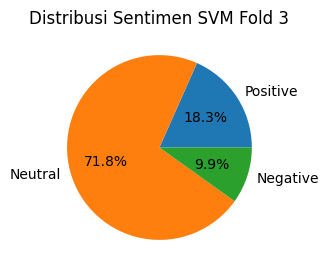


Classification Report SVM Fold 3
              precision    recall  f1-score   support

    Positive       0.65      0.60      0.63       113
     Neutral       0.85      0.90      0.87       385
    Negative       0.62      0.51      0.56        69

    accuracy                           0.79       567
   macro avg       0.71      0.67      0.69       567
weighted avg       0.78      0.79      0.79       567


===== SVM FOLD 4 =====
Parameter SVM Terbaik: {'clf__C': 100}

Sentiment Distribution SVM Fold 4
          Jumlah  Persentase (%)
Positive     105           18.52
Neutral      412           72.66
Negative      50            8.82


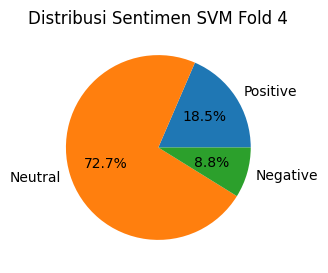


Classification Report SVM Fold 4
              precision    recall  f1-score   support

    Positive       0.67      0.62      0.64       113
     Neutral       0.84      0.90      0.87       385
    Negative       0.68      0.49      0.57        69

    accuracy                           0.79       567
   macro avg       0.73      0.67      0.69       567
weighted avg       0.78      0.79      0.79       567


===== SVM FOLD 5 =====
Parameter SVM Terbaik: {'clf__C': 10}

Sentiment Distribution SVM Fold 5
          Jumlah  Persentase (%)
Positive     101           17.81
Neutral      410           72.31
Negative      56            9.88


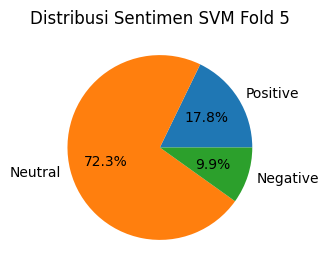


Classification Report SVM Fold 5
              precision    recall  f1-score   support

    Positive       0.72      0.65      0.68       113
     Neutral       0.86      0.91      0.88       385
    Negative       0.66      0.54      0.59        69

    accuracy                           0.81       567
   macro avg       0.75      0.70      0.72       567
weighted avg       0.81      0.81      0.81       567



In [ ]:
# Iterasi untuk setiap fold
for train_idx, eval_idx in skf.split(data["normalized_text"], data["label"]):
    print(f"\n===== SVM FOLD {fold_svm} =====")

    # Bagi data menjadi data latih (train) dan data evaluasi (eval)
    X_train, y_train = data["normalized_text"].iloc[train_idx], data["label"].iloc[train_idx]
    X_eval, y_eval = data["normalized_text"].iloc[eval_idx], data["label"].iloc[eval_idx]

    # Grid Search & Training SVM
    svm_grid = GridSearchCV(svm_pipeline, svm_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
    svm_grid.fit(X_train, y_train)

    print(f"Parameter SVM Terbaik: {svm_grid.best_params_}")

    # Prediksi
    y_pred_svm = svm_grid.best_estimator_.predict(X_eval)

    # Hitung metrik evaluasi
    acc = accuracy_score(y_eval, y_pred_svm)
    prec, rec, f1, _ = precision_recall_fscore_support(y_eval, y_pred_svm, average='macro', zero_division=0)

    svm_results.append({
        "fold": fold_svm,
        "best_params": svm_grid.best_params_,
        "accuracy_svm": acc,
        "precision_macro_svm": prec,
        "recall_macro_svm": rec,
        "f1_macro_svm": f1
    })

    # Hitung distribusi sentimen
    sentiment_dist = pd.Series(y_pred_svm).value_counts().sort_index()
    sentiment_dist.index = sentiment_dist.index.map(label_map)
    sentiment_summary = pd.DataFrame({
        "Jumlah": sentiment_dist,
        "Persentase (%)": (sentiment_dist / sentiment_dist.sum() * 100).round(2)
    })

    print(f"\nSentiment Distribution SVM Fold {fold_svm}")
    print(sentiment_summary)

    # Pie Chart Distribusi Sentimen
    sentiment_summary["Jumlah"].plot(kind="pie", autopct="%1.1f%%", figsize=(3,3), title=f"Distribusi Sentimen SVM Fold {fold_svm}")
    plt.ylabel("")
    plt.show()

    # Classification Report
    print(f"\nClassification Report SVM Fold {fold_svm}")
    print(classification_report(y_eval, y_pred_svm, target_names=["Positive", "Neutral", "Negative"]))

    # Lanjut ke fold berikutnya
    fold_svm += 1

In [ ]:
f1_svm = [result["f1_macro_svm"] for result in svm_results]

print("F1-Score Macro SVM per Fold:", f1_svm)

F1-Score Macro SVM per Fold: [0.7117214760965395, 0.696447922249829, 0.6868218281121506, 0.6931256519506034, 0.7190872861929113]


In [ ]:
avg_accuracy_svm = np.mean([result["accuracy_svm"] for result in svm_results])
avg_precision_svm = np.mean([result["precision_macro_svm"] for result in svm_results])
avg_recall_svm = np.mean([result["recall_macro_svm"] for result in svm_results])
avg_f1score_svm = np.mean([result["f1_macro_svm"] for result in svm_results])

print(f"Average SVM Accuracy: {avg_accuracy_svm:.4f}")
print(f"Average SVM Precision: {avg_precision_svm:.4f}")
print(f"Average SVM Recall: {avg_recall_svm:.4f}")
print(f"Average SVM F1-Score: {avg_f1score_svm:.4f}")

Average SVM Accuracy: 0.7980
Average SVM Precision: 0.7297
Average SVM Recall: 0.6812
Average SVM F1-Score: 0.7014
